# Feature Importance

### Escolha do modelo campeão

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LER OS RESULTADOS E IDENTIFICAR O CAMPEÃO
df_resultados = pd.read_csv('resultados_experimentos.csv')

# Ordenando pelo F1 Score para achar o melhor
campeao = df_resultados.sort_values(by='F1 Score', ascending=False).iloc[0]

print("--- MODELO CAMPEÃO IDENTIFICADO ---")
print(campeao)
print("\n")

--- MODELO CAMPEÃO IDENTIFICADO ---
Modelo                                   Regressão Logística
Descrição           normalizacao minmax, balanceamento under
Acurácia                                            0.831579
Precisão                                            0.833333
Recall                                              0.833333
Specificity                                         0.829787
F1 Score                                            0.833333
Tempo em Segundo                                     0.00216
Name: 4, dtype: object




### Treinamento do Modelo

In [2]:
from pandas import read_csv

# Carregando os dados
arquivo = 'dados_dataset/dados_limpos.csv'
dados = read_csv(arquivo)
print("dataset carregado")

dataset carregado


Random oversampling:
Attrition
0    1233
1    1233
Name: count, dtype: int64


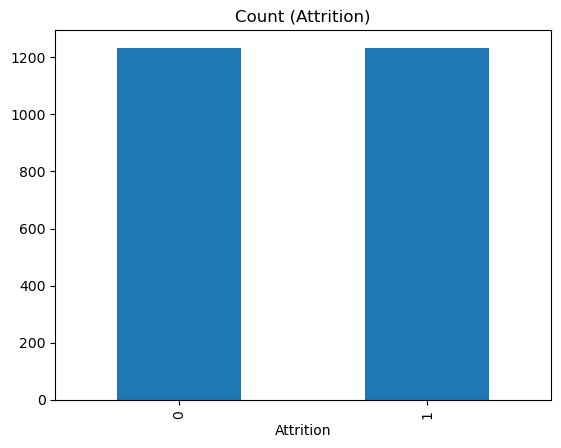

In [3]:
from sklearn import preprocessing
import pandas as pd

# 1. Garantindo que Attrition seja numérico
label_encoder = preprocessing.LabelEncoder()
dados['Attrition'] = label_encoder.fit_transform(dados['Attrition'])

# 2. Contagem das classes
count_class_0, count_class_1 = dados.Attrition.value_counts()

# 3. Separando as classes
target_class_0 = dados[dados['Attrition'] == 0]
target_class_1 = dados[dados['Attrition'] == 1]

# 4. Oversampling: pegando amostras da classe 1 com reposição (replace=True)
dados_class_1_over = target_class_1.sample(count_class_0, replace=True)

# 5. Combinando os datasets
dados_over = pd.concat([target_class_0, dados_class_1_over], axis=0)

# Verificação
print('Random oversampling:')
print(dados_over.Attrition.value_counts())
dados_over.Attrition.value_counts().plot(kind='bar', title='Count (Attrition)');

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Separando os dados 
X = dados_over.drop('Attrition', axis=1).values
Y = dados_over['Attrition'].values

# 2. Divisão 
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. Padronização 
scaler = MinMaxScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Instancia o modelo
modelo = LogisticRegression()

# Treina usando os dados padronizados
modelo.fit(X_train_scaled, y_train)

# Faz a previsão no conjunto de teste 
X_test_scaled = scaler.transform(X_test)
y_pred = modelo.predict(X_test_scaled)

### Aplicação Feature Importance

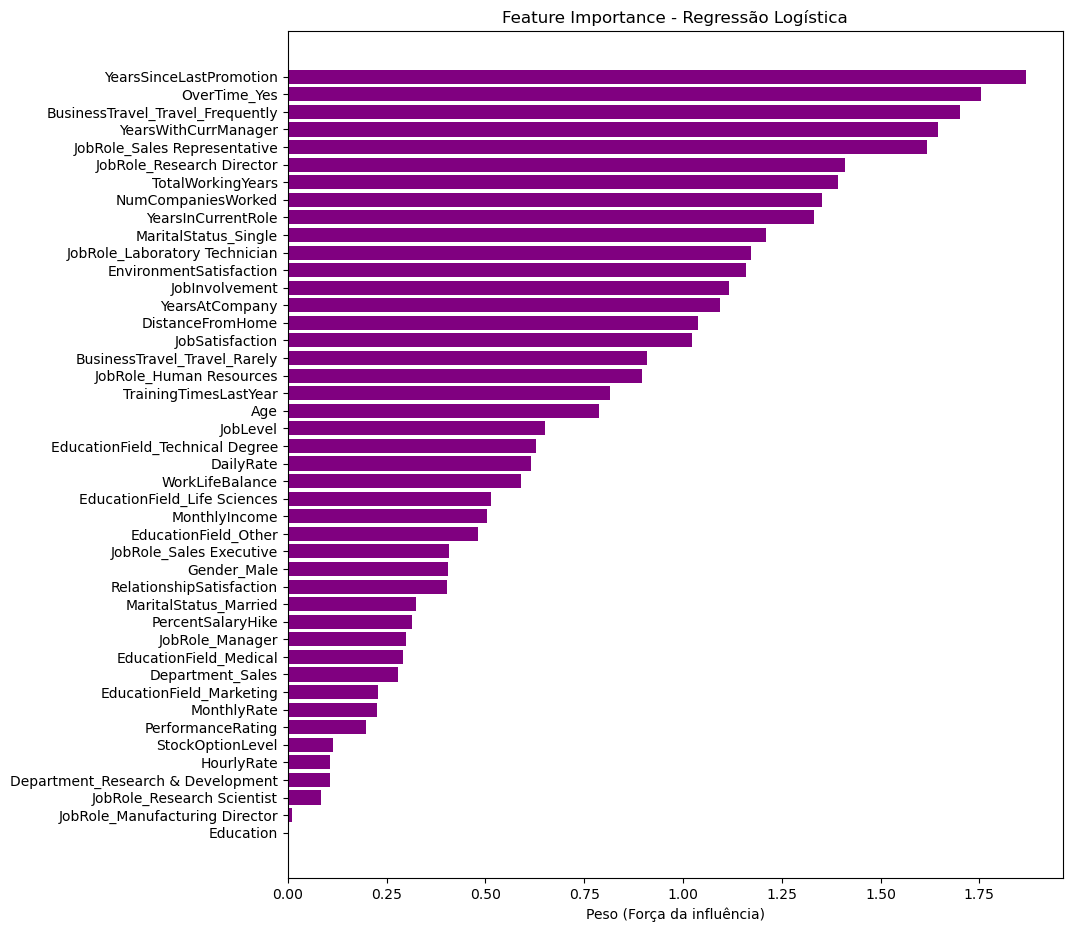

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraindo os coeficientes (pesos)
# O modelo.coef_[0] nos dá o peso de cada feature
importancia = abs(modelo.coef_[0])

df_importancia = pd.DataFrame({
    'Feature': dados.drop('Attrition', axis=1).columns,
    'Importancia': importancia
})

# Ordenando do mais importante para o menos importante
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# Plotando o gráfico
plt.figure(figsize=(10, 11))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='purple')
plt.title("Feature Importance - Regressão Logística")
plt.xlabel("Peso (Força da influência)")
plt.show()